## Pairwise Distance Matrix Optimization via torch.cdist

**Goals**  
* Understand memory allocation, tensor shapes, and vectorization when computing spatial topologies for $SE(3)$-equivariant networks.
* Benchmark pure Python loops, PyTorch broadcasting, and CUDA-optimized `torch.cdist` kernels on $C_\alpha$ coordinates to quantify speed and memory overhead.

**Background**  
*Understanding Pairwise Distances*  
Consider a 4-residue protein. Its spatial state tensor $\mathbf{X}$ represents the 3D position $(x, y, z)$ of each $C_\alpha$ atom in 3D space (typically measured in Ångströms).  

$$\mathbf{X} = \begin{bmatrix} x_1 & y_1 & z_1 \\ x_2 & y_2 & z_2 \\ x_3 & y_3 & z_3 \\ x_4 & y_4 & z_4 \end{bmatrix} = \begin{bmatrix} 12.451 & 8.320 & 21.045 \\ 15.210 & 9.814 & 23.112 \\ 18.042 & 7.410 & 25.301 \\ 21.115 & 8.905 & 27.840 \end{bmatrix} \in \mathbb{R}^{4 \times 3}$$

Using $\mathbf{X}$, we compute distances between all residue pairs. For example, the distance between residue 1 and residue 2 is:
$$d_{12} = \sqrt{(12.451 - 15.210)^2 + (8.320 - 9.814)^2 + (21.045 - 23.112)^2}$$

Computing all pairs yields a symmetric distance matrix $\mathbf{D}$:
$$\mathbf{D} = \begin{bmatrix} 0.000 & 3.757 & 7.159 & 11.144 \\ 3.757 & 0.000 & 4.020 & 7.545 \\ 7.159 & 4.020 & 0.000 & 4.062 \\ 11.144 & 7.545 & 4.062 & 0.000 \end{bmatrix} \in \mathbb{R}^{4 \times 4}$$

Note that $\mathbf{D}_{ii} = 0$ and $\mathbf{D}_{ij} = \mathbf{D}_{ji}$.

Generally, for a protein with $N$ residues, the spatial coordinates generate an $N \times N$ matrix $\mathbf{D}$, where $\mathbf{D}_{ij}$ is the Euclidean distance between residue $i$ and residue $j$:
$$\mathbf{D}_{ij} = \|\mathbf{r}_i - \mathbf{r}_j\|_2 = \sqrt{(x_i - x_j)^2 + (y_i - y_j)^2 + (z_i - z_j)^2}$$

### Precision & Float Types in Molecular Modeling

PyTorch defaults to single precision (`torch.float32`). While ideal for GPU throughput, floating-point arithmetic introduces subtle edge cases in structural biology:

* **Square Roots Near Zero:** The derivative of $\sqrt{x}$ approaches infinity as $x \to 0$ ($\frac{d}{dx}\sqrt{x} = \frac{1}{2\sqrt{x}}$). On the diagonal where $x_i = x_j$, exact subtraction can yield tiny negative values (e.g., $-10^{-8}$) due to precision limits. Taking $\sqrt{-10^{-8}}$ produces `NaN` gradients during backpropagation.
* **Kernel Safeguards:** Higher-level primitives like `torch.cdist` include internal numerical clamping (e.g., `torch.clamp(x, min=1e-12)`) to ensure stability at $\mathbf{D}_{ii} = 0$, whereas naive broadcasting requires manually adding an $\epsilon$ term ($\sqrt{\text{sq\_dist} + \epsilon}$).

**Implementations to Benchmark**
1. **Explicit Loops:** Iterates over $i$ and $j$ in pure Python ($\mathcal{O}(N^2)$ runtime).
2. **Broadcasting Mechanics:** Expands $(N, 3) \to (N, 1, 3)$ and $(1, N, 3)$ to compute pairwise differences across an intermediate 3D tensor of shape $(N, N, 3)$ using PyTorch C++/CUDA routines.
3. **Optimized Kernels (`torch.cdist`):** Uses specialized C++/CUDA primitives (BLAS/GEMM) that avoid allocating massive $(N, N, 3)$ intermediate tensors in memory by leveraging expansion tricks ($\|\mathbf{a} - \mathbf{b}\|^2 = \|\mathbf{a}\|^2 + \|\mathbf{b}\|^2 - 2\mathbf{a} \cdot \mathbf{b}$).

**Experiment**  
We will benchmark these three methods across Par-6 ($N=94$) and Lgl ($N=860$) to quantify execution speed, memory footprint, and numerical stability.

---

### Results Summary
#### 1. Execution Time (milliseconds)
Par-6 
| Method | Mean | Std | Median | IQR | Min | Max |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Explicit Loops** | 908.07 | 123.45 | 853.59 | 67.65 | 807.30 | 1245.74 |
| **Broadcasting** | 0.40 | 0.09 | 0.37 | 0.03 | 0.34 | 0.72 |
| **torch.cdist** | 0.26 | 0.03 | 0.24 | 0.04 | 0.23 | 0.35 |

Lgl
| Method | Mean | Std | Median | IQR | Min | Max |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Explicit Loops** | 52670.19 | 12469.32 | 46794.49 | 25298.31 | 42624.27 | 73981.47 |
| **Broadcasting** | 2.95 | 0.71 | 2.64 | 0.75 | 2.30 | 5.07 |
| **torch.cdist** | 0.67 | 0.28 | 0.61 | 0.06 | 0.55 | 1.85 |

#### 2. Peak RAM Allocation (megabytes)
Par-6 
| Method | Mean | Std | Median | IQR | Min | Max |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Explicit Loops** | 0.36 | 0.0 | 0.36 | 0.0 | 0.36 | 0.36 |
| **Broadcasting** | 0.00 | 0.0 | 0.00 | 0.0 | 0.00 | 0.00 |
| **torch.cdist** | 0.00 | 0.0 | 0.00 | 0.0 | 0.00 | 0.00 |

Lgl
| Method | Mean | Std | Median | IQR | Min | Max |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Explicit Loops** | 28.29 | 0.0 | 28.29 | 0.0 | 28.29 | 28.29 |
| **Broadcasting** | 0.00 | 0.0 | 0.00 | 0.0 | 0.00 | 0.00 |
| **torch.cdist** | 0.00 | 0.0 | 0.00 | 0.0 | 0.00 | 0.00 |

#### Precision and Float types
Using Par-6 and Lgl, we compared how the pairwise distance matrices differ when using float32 vs float64.
| Protein | Residues (N) | Max Abs Error (Å) | Mean Abs Error (Å) | Coords Float32 Size (KB) | Coords Float64 Size (KB) |
| :---: | :---: | :---: | :---: | :---: | :---: |
| Par-6 | 94 | 8.84e-02 | 2.03e-04 | 1.10 | 2.20 |
| Lgl | 860 | 1.25e-01 | 5.80e-05 | 10.08 | 20.16 |

### Key Insights & Conclusions

1. **Computational Efficiency:**
   * `torch.cdist` outperforms all other methods across both benchmark targets, running **~3,500x faster** than pure Python loops on Par-6 ($N=94$) and **~78,000x faster** on Lgl ($N=860$).
   * Broadcasting provides comparable asymptotic performance to `cdist` but incurs a slight memory overhead due to creating explicit intermediate 3D tensor shapes `(N, 1, 3)` and `(1, N, 3)` during execution.

2. **Precision Requirements in Biological Mechanics:**
   * **Distance Cutoffs & Contact Maps:** In CIF files, atomic coordinates are recorded to 3 decimal places ($0.001\,\text{Å}$). The mean absolute error introduced by `float32` ($2.03 \times 10^{-4}\,\text{Å}$ for Par-6 and $5.80 \times 10^{-5}\,\text{Å}$ for Lgl) is negligible for static geometric filters.
   * **Normal Mode Analysis (NMA) & Elastic Network Models (ENM):** Taking second derivatives to construct Hessian/Kirchhoff matrices and performing eigen-decomposition or matrix inversions ($K^{-1}$) can amplify tiny $10^{-4}\,\text{Å}$ single-precision roundoff errors into artificial low-frequency mode shifts.

3. **Pipeline Standard:**
   * Based on these benchmarks, our `polarity-engine` pipeline will standardize on **`torch.cdist` with `float64` (double precision)** for structural mechanics and normal mode computations.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import gc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import time
import torch
import tracemalloc

from collections.abc import Callable
from pathlib import Path
from scipy import stats
from statannotations.Annotator import Annotator
from typing import Any

from polarity_engine.parsers import StructureParser

In [3]:
data_dir = Path("../../data")
data_dir.mkdir(parents=True, exist_ok=True)

input_dir = data_dir / "input"
input_dir.mkdir(parents=True, exist_ok=True)

### Prepare the coordinate data to be used in the experiments

In [4]:
TEST_CIF_Paht = input_dir/ "8r3y.cif"
test_coords = StructureParser.get_alpha_carbon_coordinates(TEST_CIF_Paht)

lgl_coords = test_coords["L"]["coords"]
par6_coords = test_coords["P"]["coords"]


### Calculate the Euclidean distance by 3 different methods

In [5]:
def calculate_pairwise_distance_by_explicit_loops(coords: np.ndarray) -> np.ndarray:
    """
    Calculate the Euclidean distance between each pair of alpha-carbons by explicit python loop.

    Args:
        coords: a (N x 3) numpy array representing the x, y, z coordinates of each 
          alpha-carbon in a N-residue protein structure

    Returns:
        a (N x N) numpy array representing the Euclidean distance between each
          residue pair
    """
    residue_num = len(coords)
    if residue_num < 1:
        raise ValueError("The coordinate array is empty.")
    output_list = []

    for i in range(residue_num):
        row = []
        for j in range(residue_num):
            euclidean_dist = np.sqrt(
                (coords[i][0] - coords[j][0]) ** 2 +
                (coords[i][1] - coords[j][1]) ** 2 +
                (coords[i][2] - coords[j][2]) ** 2
            )
            row.append(euclidean_dist)
        output_list.append(row)

    return np.array(output_list)


def calculate_euclidean_distance_by_broadcasting(coords: np.ndarray) -> np.ndarray:
    """
    Calculate the Euclidean distance between each pair of alpha-carbons by vectorization.

    Args:
        coords: a (N x 3) numpy array representing the x, y, z coordinates of each 
          alpha-carbon in a N-residue protein structure

    Returns:
        a (N x N) numpy array representing the Euclidean distance between each
          residue pair
    """
    # Expand dimensions
    c_i = coords.unsqueeze(1)  # shape: (N, 1, 3)
    c_j = coords.unsqueeze(0)  # shape: (1, N, 3)

    # Compute vector differences across intermediate (N, N, 3) shape
    # Every diff[i, j] now contains the 3D displacement vector
    # (x_i - x_j, y_i - y_j, z_i - z_j).
    diff = c_i - c_j

    # Compute Euclidean norm across coordinate axis (dim=-1) by
    # shrinking the shape from (N, N, 3) down to (N, N).
    dist_matrix = torch.linalg.vector_norm(diff, ord=2, dim=-1)

    return dist_matrix


def run_dist_calculation_by_broadcasting_on_gpu(input_coords: np.ndarray) -> np.ndarray:
    """
    Run calculate_euclidean_distance_by_broadcasting on GPU.

    Args:
        input_coords: a (N x 3) numpy array representing the x, y, z coordinates of each 
          alpha-carbon in a N-residue protein structure
    Returns:
        a (N x N) numpy array representing the Euclidean distance between each
          residue pair
    """
    # Convert NumPy array to PyTorch Tensor
    coords = torch.from_numpy(input_coords)

    # Send tensor to GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    coords = coords.to(device)

    dist_matrix = calculate_euclidean_distance_by_broadcasting(coords)

    # Convert back to NumPy (if needed for plotting/seaborn)
    # Note: Tensor must be on CPU before converting back to NumPy
    np_dist_matrix = dist_matrix.cpu().numpy()

    return np_dist_matrix


In [6]:
def profile_pairwise_distance_matrix_generation(
    dist_func: Callable[[Any], Any], 
    coords: Any, 
    runs: int = 10
) -> tuple[list[float], list[float]]:
    """
    Profiles execution time (ms) and peak memory (MB) for a distance matrix function.

    Args:
        dist_func: Function that takes `coords` and returns a distance matrix.
        coords: Input coordinates (NumPy array or PyTorch Tensor).
        runs: Number of benchmark iterations.

    Returns:
        Tuple of (list of execution times in ms, list of peak memory usages in MB)
    """
    if runs < 1:
        raise ValueError("The number of benchmark runs must be at least 1.")
    
    times_ms = []
    peak_mbs = []

    with torch.no_grad(): # Prevents PyTorch from allocating memory for backpropagation computation graphs during benchmark loops.
        # Warm-up run (populates cache & JIT/module allocations)
        _ = dist_func(coords)

        for _ in range(runs):
            gc.collect()  # Clean Python heap before each run

            tracemalloc.start()
            start_time = time.perf_counter()

            _ = dist_func(coords)

            end_time = time.perf_counter()
            _, peak_mem = tracemalloc.get_traced_memory()
            tracemalloc.stop()

            times_ms.append((end_time - start_time) * 1000)
            peak_mbs.append(peak_mem / (1024 * 1024))

    return times_ms, peak_mbs


In [7]:
# Benchmark the 3 methods with Par-6 (96 residues)
runs = 20
# explicit loops
times_ms_loop_p, peak_mbs_loop_p = profile_pairwise_distance_matrix_generation(
    calculate_pairwise_distance_by_explicit_loops,
    par6_coords, runs=runs)

# broadcasting
times_ms_vector_p, peak_mbs_vector_p = profile_pairwise_distance_matrix_generation(
    run_dist_calculation_by_broadcasting_on_gpu,
    par6_coords, runs=runs
)

# torch.cdist
coords_tensor_par6 = torch.from_numpy(par6_coords).float()
times_ms_cdist_p, peak_mbs_cdist_p = profile_pairwise_distance_matrix_generation(
    dist_func=lambda x: torch.cdist(x, x),
    coords=coords_tensor_par6, runs=runs
)

In [8]:
# Benchmark the 3 methods with Lgl (860 residues)
runs = 20
# explicit loops
times_ms_loop_l, peak_mbs_loop_l = profile_pairwise_distance_matrix_generation(
    calculate_pairwise_distance_by_explicit_loops,
    lgl_coords, runs=runs)

# broadcasting
times_ms_vector_l, peak_mbs_vector_l = profile_pairwise_distance_matrix_generation(
    run_dist_calculation_by_broadcasting_on_gpu,
    lgl_coords, runs=runs
)

# torch.cdist
coords_tensor_lgl = torch.from_numpy(lgl_coords).float()
times_ms_cdist_l, peak_mbs_cdist_l = profile_pairwise_distance_matrix_generation(
    dist_func=lambda x: torch.cdist(x, x),
    coords=coords_tensor_lgl, runs=runs
)

### Analyze the data

In [9]:
df_measured_time = pd.DataFrame(
    {
        "explicit_loop_time_par6": times_ms_loop_p,
        "explicit_loop_time_lgl": times_ms_loop_l,
        "broadcasting_time_par6": times_ms_vector_p,
        "broadcasting_time_lgl": times_ms_vector_l,
        "torch_cdist_time_par6": times_ms_cdist_p,
        "torch_cdist_time_lgl": times_ms_cdist_l
    }
)

df_measured_memory = pd.DataFrame(
    {
        "explicit_loop_memory_par6": peak_mbs_loop_p,
        "explicit_loop_memory_lgl": peak_mbs_loop_l,
        "broadcasting_memory_par6": peak_mbs_vector_p,
        "broadcasting_memory_lgl": peak_mbs_vector_l,
        "torch_cdist_memory_par6": peak_mbs_cdist_p,
        "torch_cdist_memory_lgl": peak_mbs_cdist_l
    }
)

In [10]:
# Descriptive summary table
resources = ["time", "memory"]
for i, df in enumerate([df_measured_time, df_measured_memory]):

    df = pd.DataFrame(
        {
            "Mean": df.mean(),
            "Std": df.std(),
            "Median": df.median(),
            "IQR": df.quantile(0.75)
            - df.quantile(0.25),
            "Min": df.min(),
            "Max": df.max(),
        }
    )
    
    print(f"=== DESCRIPTIVE STATISTICS (N = 20) for {resources[i]}===")
    display(df.round(2))
    

=== DESCRIPTIVE STATISTICS (N = 20) for time===


,Mean,Std,Median,IQR,Min,Max
explicit_loop_time_par6,908.07,123.45,853.59,67.65,807.30,1245.74
explicit_loop_time_lgl,52670.19,12469.32,46794.49,25298.31,42624.27,73981.47
broadcasting_time_par6,0.40,0.09,0.37,0.03,0.34,0.72
broadcasting_time_lgl,2.95,0.71,2.64,0.75,2.30,5.07
torch_cdist_time_par6,0.26,0.03,0.24,0.04,0.23,0.35
torch_cdist_time_lgl,0.67,0.28,0.61,0.06,0.55,1.85


=== DESCRIPTIVE STATISTICS (N = 20) for memory===


,Mean,Std,Median,IQR,Min,Max
explicit_loop_memory_par6,0.36,0.0,0.36,0.0,0.36,0.36
explicit_loop_memory_lgl,28.29,0.0,28.29,0.0,28.29,28.29
broadcasting_memory_par6,0.00,0.0,0.00,0.0,0.00,0.00
broadcasting_memory_lgl,0.00,0.0,0.00,0.0,0.00,0.00
torch_cdist_memory_par6,0.00,0.0,0.00,0.0,0.00,0.00
torch_cdist_memory_lgl,0.00,0.0,0.00,0.0,0.00,0.00


In [11]:
def calculate_fold_change(df: pd.DataFrame, test_column: str, ref_column: str) -> float:
    """
    Calculate the fold change for a given pair of methods

    Args:
        df: a dataframe that contains execution time and memory usage of competing methods.
        test_column: the name of the column to be tested.
        ref_column: the name of the column to be used as reference.
    Returns:
        fold change calculated for the provided pair of methods.
    """
    return df[ref_column].median()/df[test_column].median()


def calculate_percent_reduction(df: pd.DataFrame, test_column: str, ref_column: str) -> float:
    """
    Calculate the reduction for a given pair of moethods

    Args:
        df: a dataframe that contains execution time and memory usage of competing methods.
        test_column: the name of the column to be tested.
        ref_column: the name of the column to be used as reference.
    Returns:
        percent reduction calculated for the provided pair of methods.
    """
    return (
        1
        - (
            df[test_column].median()
            / df[ref_column].median()
        )
    ) * 100


In [12]:
# For Par-6
median_time_speedup_vector_p = calculate_fold_change(
    df_measured_time, "broadcasting_time_par6", "explicit_loop_time_par6")
median_time_speedup_cdist_p = calculate_fold_change(
    df_measured_time, "torch_cdist_time_par6", "explicit_loop_time_par6")

median_mem_reduction_vector_p = calculate_percent_reduction(
    df_measured_memory, "broadcasting_memory_par6", "explicit_loop_memory_par6")
median_mem_reduction_cdist_p = calculate_percent_reduction(
    df_measured_memory, "torch_cdist_memory_par6", "explicit_loop_memory_par6")

print("\n=== Performance gain for Par-6 ===")
print("• Broadcasting")
print(f"\tExecution time: {median_time_speedup_vector_p:.2f}x faster (median)")
print(f"\tPeak RAM: {median_mem_reduction_vector_p:.1f}% (median) reduction")
print("• torch.cdict")
print(f"\tExecution time: {median_time_speedup_cdist_p:.2f}x faster (median)")
print(f"\tPeak RAM: {median_mem_reduction_cdist_p:.1f}% (median) reduction")


=== Performance gain for Par-6 ===
• Broadcasting
	Execution time: 2318.95x faster (median)
	Peak RAM: 99.8% (median) reduction
• torch.cdict
	Execution time: 3529.31x faster (median)
	Peak RAM: 99.9% (median) reduction


In [13]:
# Time comparison
w_time_stat_par6, w_time_p_par6 = stats.wilcoxon(
    df_measured_time["explicit_loop_time_par6"],
    df_measured_time["broadcasting_time_par6"],
)
# Cohen's d for Time
diff_time_par6 = (
    df_measured_time["explicit_loop_time_par6"]
    - df_measured_time["broadcasting_time_par6"]
)
cohen_d_time_par6 = np.mean(diff_time_par6) / np.std(diff_time_par6, ddof=1)

# Memory comparison
w_mem_stat_par6, w_mem_p_par6 = stats.wilcoxon(
    df_measured_memory["explicit_loop_memory_par6"],
    df_measured_memory["broadcasting_memory_par6"],
)
# Cohen's d for Memory
diff_mem_par6 = (
    df_measured_memory["explicit_loop_memory_par6"]
    - df_measured_memory["broadcasting_memory_par6"]
)
cohen_d_mem_par6 = np.mean(diff_mem_par6) / np.std(diff_mem_par6, ddof=1)

print("\n=== HYPOTHESIS TESTING (Wilcoxon Signed-Rank Test & Cohen's d) ===")
print(
    f"• Time   : W = {w_time_stat_par6:.0f}, p = {w_time_p_par6:.2e} | Cohen's d = {cohen_d_time_par6:.3f}")
print(
    f"• Memory : W = {w_mem_stat_par6:.0f}, p = {w_mem_p_par6:.2e} | Cohen's d = {cohen_d_mem_par6:.3f}")


=== HYPOTHESIS TESTING (Wilcoxon Signed-Rank Test & Cohen's d) ===
• Time   : W = 0, p = 1.91e-06 | Cohen's d = 7.353
• Memory : W = 0, p = 1.91e-06 | Cohen's d = 477.598


In [14]:
# For Lgl
median_time_speedup_vector_l = calculate_fold_change(
    df_measured_time, "broadcasting_time_lgl", "explicit_loop_time_lgl")
median_time_speedup_cdist_l = calculate_fold_change(
    df_measured_time, "torch_cdist_time_lgl", "explicit_loop_time_lgl")

median_mem_reduction_vector_l = calculate_percent_reduction(
    df_measured_memory, "broadcasting_memory_lgl", "explicit_loop_memory_lgl")
median_mem_reduction_cdist_l = calculate_percent_reduction(
    df_measured_memory, "torch_cdist_memory_lgl", "explicit_loop_memory_lgl")

print("\n=== Performance gain for Lgl ===")
print("• Broadcasting")
print(f"\tExecution time: {median_time_speedup_vector_l:.2f}x faster (median)")
print(f"\tPeak RAM: {median_mem_reduction_vector_l:.1f}% (median) reduction")
print("• torch.cdict")
print(f"\tExecution time: {median_time_speedup_cdist_l:.2f}x faster (median)")
print(f"\tPeak RAM: {median_mem_reduction_cdist_l:.1f}% (median) reduction")


=== Performance gain for Lgl ===
• Broadcasting
	Execution time: 17696.48x faster (median)
	Peak RAM: 100.0% (median) reduction
• torch.cdict
	Execution time: 76915.60x faster (median)
	Peak RAM: 100.0% (median) reduction


In [15]:
# Time comparison
w_time_stat_lgl, w_time_p_lgl = stats.wilcoxon(
    df_measured_time["explicit_loop_time_lgl"],
    df_measured_time["broadcasting_time_lgl"],
)
# Cohen's d for Time
diff_time_lgl = (
    df_measured_time["explicit_loop_time_lgl"]
    - df_measured_time["broadcasting_time_lgl"]
)
cohen_d_time_lgl = np.mean(diff_time_lgl) / np.std(diff_time_lgl, ddof=1)

# Memory comparison
w_mem_stat_lgl, w_mem_p_lgl = stats.wilcoxon(
    df_measured_memory["explicit_loop_memory_lgl"],
    df_measured_memory["broadcasting_memory_lgl"],
)
# Cohen's d for Memory
diff_mem_lgl = (
    df_measured_memory["explicit_loop_memory_lgl"]
    - df_measured_memory["broadcasting_memory_lgl"]
)
cohen_d_mem_lgl = np.mean(diff_mem_lgl) / np.std(diff_mem_lgl, ddof=1)

print("\n=== HYPOTHESIS TESTING (Wilcoxon Signed-Rank Test & Cohen's d) ===")
print(
    f"• Time   : W = {w_time_stat_lgl:.0f}, p = {w_time_p_lgl:.2e} | Cohen's d = {cohen_d_time_lgl:.3f}")
print(
    f"• Memory : W = {w_mem_stat_lgl:.0f}, p = {w_mem_p_lgl:.2e} | Cohen's d = {cohen_d_mem_lgl:.3f}")


=== HYPOTHESIS TESTING (Wilcoxon Signed-Rank Test & Cohen's d) ===
• Time   : W = 0, p = 1.91e-06 | Cohen's d = 4.224
• Memory : W = 0, p = 1.91e-06 | Cohen's d = 201186.065


In [16]:
# Reshape data into long format for clean Seaborn + Statannotations integration
df_long_time = pd.melt(
    df_measured_time,
    var_name="methods_protein",
    value_name="Value",
)
# Split the variable column into distinct Parser and Metric columns
df_long_time["Method"] = df_long_time["methods_protein"].apply(
    lambda x: "explicit_loop" if "explicit_loop" in x else (
        "broadcasting" if "broadcasting" in x else "torch.cdist")
)
df_long_time["Protein"] = df_long_time["methods_protein"].apply(
    lambda x: "Lgl" if "lgl" in x else "Par-6"
)

df_long_mem = pd.melt(
    df_measured_memory,
    var_name="methods_protein",
    value_name="Value",
)
# Split the variable column into distinct Parser and Metric columns
df_long_mem["Method"] = df_long_mem["methods_protein"].apply(
    lambda x: "explicit_loop" if "explicit_loop" in x else (
        "broadcasting" if "broadcasting" in x else "torch.cdist")
)
df_long_mem["Protein"] = df_long_mem["methods_protein"].apply(
    lambda x: "Lgl" if "lgl" in x else "Par-6"
)

# Define the pairs to compare
pairs = [
    ("explicit_loop", "broadcasting"),
    ("explicit_loop", "torch.cdist"),
    ("broadcasting", "torch.cdist")
]


In [17]:
def plot_benchmark_distribution(
    data: pd.DataFrame,
    x: str = "Method",
    y: str = "Value",
    hue: str = "Protein",
    log_scale: bool = True,
    ax: plt.Axes | None = None,
    palette: str = "Set2",
    jitter: float = 0.2,
    alpha: float = 0.25,
    stripplot_color: str = "black",
) -> plt.Axes:
    """Plots a combined Seaborn boxplot and stripplot overlay for benchmark comparisons.

    Args:
        data: DataFrame in long format containing the benchmarking results.
        x: Column name for the categorical x-axis (e.g., Method).
        y: Column name for the numerical metric (e.g., Time in ms or Memory in
          MB).
        hue: Column name for secondary grouping (e.g., Protein or Structure
          size).
        log_scale: Whether to apply log scale to the y-axis.
        ax: Matplotlib axes object. If None, uses current axes.
        palette: Seaborn color palette name for the boxplot.
        jitter: Amount of jitter for the stripplot points.
        alpha: Transparency for the stripplot points.
        stripplot_color: Color for the overlaid stripplot points.

    Returns:
        ax: Matplotlib axes object with the plots applied.
    """
    if ax is None:
        ax = plt.gca()

    # Shared kwargs between both plots to guarantee alignment
    shared_kwargs = {
        "data": data,
        "x": x,
        "y": y,
        "hue": hue,
        "log_scale": log_scale,
        "ax": ax,
    }

    sns.boxplot(
        **shared_kwargs,
        showfliers=False,
        palette=palette,
        showmeans=True,
        meanprops={
            "marker": "o",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
        },
    )

    sns.stripplot(
        **shared_kwargs,
        dodge=True,
        color=stripplot_color,
        alpha=alpha,
        jitter=jitter,
        legend=False,
    )

    handles, labels = ax.get_legend_handles_labels()
    if handles:
        num_hues = len(data[hue].unique()) if hue in data.columns else len(handles)
        ax.legend(
            handles[:num_hues],
            labels[:num_hues],
            title=hue,
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
            frameon=False,
        )

    return ax

/var/folders/vl/cjsy8yl950v05vbldt2pr2pr0000gn/T/ipykernel_8248/2988063117.py:57: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


explicit_loop vs. broadcasting: Wilcoxon test (paired samples), P_val:1.819e-12 Stat=0.000e+00
broadcasting vs. torch.cdist: Wilcoxon test (paired samples), P_val:1.819e-12 Stat=0.000e+00
explicit_loop vs. torch.cdist: Wilcoxon test (paired samples), P_val:1.819e-12 Stat=0.000e+00


/var/folders/vl/cjsy8yl950v05vbldt2pr2pr0000gn/T/ipykernel_8248/2988063117.py:57: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


explicit_loop vs. broadcasting: Wilcoxon test (paired samples), P_val:1.819e-12 Stat=0.000e+00
broadcasting vs. torch.cdist: Wilcoxon test (paired samples), P_val:1.819e-12 Stat=0.000e+00
explicit_loop vs. torch.cdist: Wilcoxon test (paired samples), P_val:1.819e-12 Stat=0.000e+00


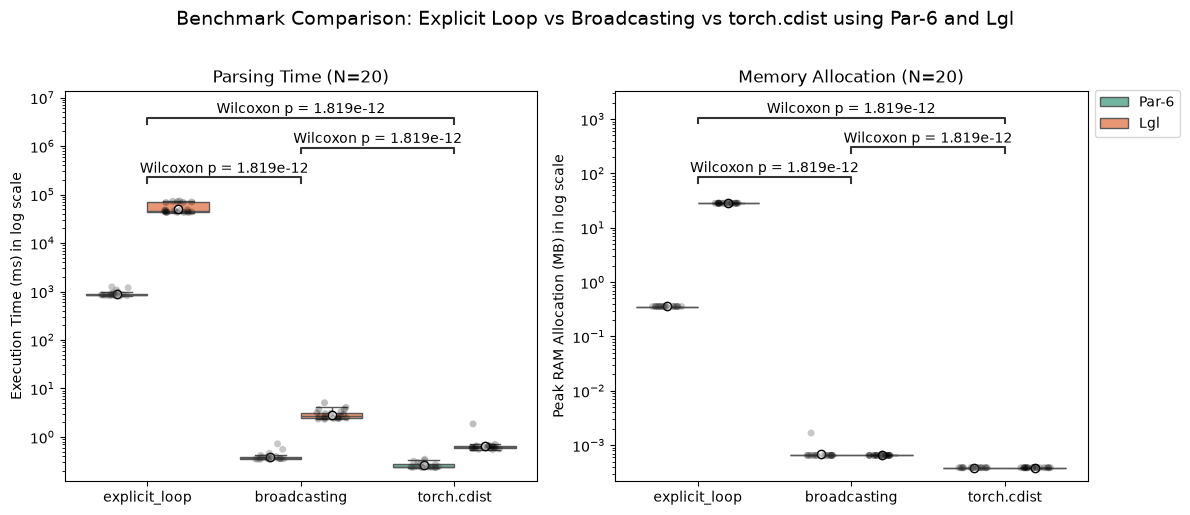

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

## --- Subplot 1: Execution Time ---
plot_benchmark_distribution(
    data=df_long_time,
    x="Method",
    y="Value",
    hue="Protein",
    log_scale=True,
    ax=ax1,
)

annotator1 = Annotator(ax1, pairs, data=df_long_time, x="Method", y="Value")
annotator1.configure(
    test="Wilcoxon", text_format="full", loc="inside", verbose=2
)
annotator1.apply_and_annotate()

ax1.set_ylabel("Execution Time (ms) in log scale")
ax1.set_xlabel("")
ax1.legend().remove()
ax1.set_title("Parsing Time (N=20)")

## --- Subplot 2: Memory Footprint ---
plot_benchmark_distribution(
    data=df_long_mem,
    x="Method",
    y="Value",
    hue="Protein",
    log_scale=True,
    ax=ax2,
)

annotator2 = Annotator(ax2, pairs, data=df_long_mem, x="Method", y="Value")
annotator2.configure(
    test="Wilcoxon", text_format="full", loc="inside", verbose=2
)
annotator2.apply_and_annotate()

ax2.set_ylabel("Peak RAM Allocation (MB) in log scale")
ax2.set_xlabel("")
ax2.set_title("Memory Allocation (N=20)")
ax2.legend(bbox_to_anchor=(1, 1.02))
fig.suptitle(
    "Benchmark Comparison: Explicit Loop vs Broadcasting vs torch.cdist using Par-6 and Lgl",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plt.show()

### Precision & float type in molecular modeling

For sensitive structural dynamics calculations—such as diagonalizing the Hessian matrix in Anisotropic Network Models (ANM) or calculating exact Normal Modes—single precision (float32) can accumulate roundoff errors across large $N \times N$ matrices.

In [ ]:
def analyze_precision_and_performance(coords_np: np.ndarray, protein_name: str) -> dict:
    """
    Compares float32 vs float64 pairwise distance precision and execution speed.

    Args:
        coords_np: a numpy array of alpha-carbon coordinates
        protein_name: name of the protein
    Returns:
        dict that summarizes the comparison results
    """
    coords_32 = torch.from_numpy(coords_np).float()
    coords_64 = torch.from_numpy(coords_np).double()

    # Compute float64 ground truth
    dist_64 = torch.cdist(coords_64, coords_64, p=2)

    # Compute float32 estimate
    dist_32 = torch.cdist(coords_32, coords_32, p=2)

    # Calculate numerical deviation (convert 32 back to 64 for subtraction)
    diff = torch.abs(dist_32.double() - dist_64)
    max_error = torch.max(diff).item()
    mean_error = torch.mean(diff).item()

    # Measure memory footprint of coordinate tensors
    mem_32_kb = (coords_32.element_size() * coords_32.nelement()) / 1024
    mem_64_kb = (coords_64.element_size() * coords_64.nelement()) / 1024

    return {
        "Protein": protein_name,
        "Residues (N)": coords_np.shape[0],
        "Max Abs Error (Å)": f"{max_error:.2e}",
        "Mean Abs Error (Å)": f"{mean_error:.2e}",
        "Coords Float32 Size (KB)": round(mem_32_kb, 2),
        "Coords Float64 Size (KB)": round(mem_64_kb, 2),
    }

# Run comparison on Par-6 and Lgl coordinate arrays
results = [
    analyze_precision_and_performance(par6_coords, "Par-6"),
    analyze_precision_and_performance(lgl_coords, "Lgl"),
]

df_precision = pd.DataFrame(results)
display(df_precision)

,Protein,Residues (N),Max Abs Error (Å),Mean Abs Error (Å),Coords Float32 Size (KB),Coords Float64 Size (KB)
0,Par-6,94,8.84e-02,2.03e-04,1.10,2.20
1,Lgl,860,1.25e-01,5.80e-05,10.08,20.16


Notes: torch.linalg.vector_norm vs sq_dist + sqrt + fill_diagonal_ to compute the Euclidean distance

torch.linalg.vector_norm calculates $\sqrt{\Delta x^2 + \Delta y^2 + \Delta z^2}$ under the hood in a single step using PyTorch's optimized linear algebra backend. It's a clean method. However, on the diagonal where $i = j$, the difference vector is $(0, 0, 0)$. PyTorch's backward pass for $\nabla \sqrt{x}$ evaluates at $x=0$, which can generate NaN gradients if you backpropagate through self-pairs.

sq_dist + sqrt + fill_diagonal_ method calculates the Euclidean distance by taking three distinct steps:
 1. Squared distances: $\Delta x^2 + \Delta y^2 + \Delta z^2$
 2. Safeguarded square root: $\sqrt{\text{sq\_dist} + \epsilon}$
 3. Hard zeroing: Forcing $\mathbf{D}_{ii} = 0.0$. 

This allows total manual control over numerical stability. Clamping at $1\times 10^{-12}$ guarantees you never take the square root of zero (or a tiny negative floating-point artifact like $-1\times 10^{-8}$), preventing NaN gradients. Setting fill_diagonal_(0.0) afterwards restores exact analytical zeros for self-distances.